## Step 1: Import the necessary libraries:


In [46]:
import numpy as np
import pandas as pd
import networkx as nx
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
import itertools
import ast
import matplotlib.pyplot as plt 
import os
import seaborn as sns
from sklearn.cluster import KMeans
from collections import Counter

## Step 2: Define the environment:


In [47]:
devices_path = "./resources/scattered_devices.csv"
tasks_path = "./resources/scattered_tasks.csv"
dataFile = "./results/mainTestResults2.csv"

#### ALL THE DEVICES


In [48]:
devices = pd.read_csv(devices_path)

devices["voltages_frequencies"] = devices["voltages_frequencies"].apply(lambda x: ast.literal_eval(x))
devices["capacitance"] = devices["capacitance"].apply(
    lambda x: ast.literal_eval(x)
)
devices["occupied_cores"] = devices["occupied_cores"].apply(
    lambda x: ast.literal_eval(x)
)
devices["powerIdle"] = devices["powerIdle"].apply(
    lambda x: ast.literal_eval(x)
)
devices["acceptableTasks"] = devices["acceptableTasks"].apply(
    lambda x: ast.literal_eval(x)
)
devices = devices.drop(["Unnamed: 0"],axis=1)

KeyError: 'occupied_cores'

### Step 2.2: Application


#### _ALL THE TASKS_


In [30]:
def regularize_any(any, mode):
    match mode:
        case 1: #time
            lower_bound =  0.00625
            upper_bound = 1
        case 2: #energy
            lower_bound = 0.0000405
            upper_bound = 1.2
        case 3: #power
            lower_bound = 0.00648
            upper_bound = 24.28 + 3.65 + 4.38412
        case 4: #cl and data in / out
            lower_bound = 1e6
            upper_bound = 1e7
        case 5: #cl and data in / out
            lower_bound = 1e6
            # upper_bound = 1e9
            upper_bound = 100e9

    # Clip the input to be within the specified bounds
    clipped_any = max(min(any, upper_bound), lower_bound)

    # Scale the energy within the bounds
    regularized_any = (clipped_any - lower_bound) / (upper_bound - lower_bound)
    regularized_any += 1e-5
    return regularized_any

In [31]:
def read_tasks(regular=False):
    tasks = pd.read_csv(tasks_path)
    tasks = tasks.sample(frac=1)
    tasks = tasks.set_index("id")
    tasks_copy = tasks.copy()
    kinds = [1, 2, 3, 4]
    for kind in kinds:
        tasks_copy[f'kind{kind}'] = tasks_copy['kind'].isin([kind]).astype(int)
    tasks_copy = tasks_copy.drop(["kind","job","dependency","mobility","status"],axis=1)
    # tasks_copy = tasks_copy.drop(["job","dependency","mobility","status"],axis=1)
    if regular :
        for column in tasks_copy.columns.values:
            tasks_copy[column] = (tasks_copy[column] - tasks_copy[column].min()) / (tasks_copy[column].max() - tasks_copy[column].min())
    return tasks, tasks_copy

## Step 4 : DDT


### Step 4.1: Initializing The tree


In [32]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from collections import Counter

class ClusterTree(nn.Module):
    def __init__(self, devices, depth, max_depth, num_epoch, counter=0):
        super(ClusterTree, self).__init__()
        self.depth = depth
        self.max_depth = max_depth

        self.epsilon = 1e-5

        self.exp_mid_bound = num_epoch * self.epsilon
        self.exploration_rate = self.exp_mid_bound + (self.exp_mid_bound / 2)
        self.exp_threshold = self.exp_mid_bound - (self.exp_mid_bound / 2)
        self.shouldExplore = 1
        self.counter = counter

        self.devices = devices
        num_features = 8
        if depth != max_depth:
            self.weights = nn.Parameter(torch.empty(num_features).normal_(mean=0, std=0.1))
            self.bias = nn.Parameter(torch.zeros(1))
        if depth == max_depth:
            self.prob_dist = nn.Parameter(torch.zeros(len(devices)))

        if depth < max_depth:
            clusters = self.cluster(self.devices)
            left_cluster = clusters[0]
            right_cluster = clusters[1]
            self.left = ClusterTree(left_cluster, depth + 1, max_depth, num_epoch)
            self.right = ClusterTree(right_cluster, depth + 1, max_depth, num_epoch)

    def forward(self, x, path=""):
        if self.depth == self.max_depth:
            return self.prob_dist, path

        val = torch.sigmoid((torch.matmul(x, self.weights) + self.bias))

        if val >= 0.5:
            right_output, right_path = self.right(x, path + "R")
            return val * right_output, right_path
        else:
            left_output, left_path = self.left(x, path + "L")
            return (1 - val) * left_output, left_path

    def get_devices(self, x):
        if self.depth == self.max_depth:
            return self.devices
        val = torch.sigmoid((torch.matmul(x, self.weights) + self.bias))

        if val >= 0.5:
            return self.right.get_devices(x)
        else:
            return self.left.get_devices(x)

    def cluster(self, devices, k=2):
        data = [self.get_pe_data(device) for _, device in devices.iterrows()]

        if len(devices) < k + 1:
            return [devices] * k
        X = np.array(data)
        kmeans = KMeans(n_clusters=k, init="random", random_state=42)
        kmeans.fit(X)

        cluster_labels = kmeans.labels_
        clusters = [devices.iloc[[]].copy() for _ in range(k)]

        # Reassign points to balance clusters
        balanced_labels = self.balance_clusters(cluster_labels, k, len(devices))

        for (index, device), label in zip(devices.iterrows(), balanced_labels):
            clusters[label] = pd.concat([clusters[label], device.to_frame().T], ignore_index=True)
            
        return clusters

    def get_pe_data(self, pe):
        capacitance = sum(pe['capacitance'])
        handleSafeTask = pe['handleSafeTask']
        kind = sum(pe['acceptableTasks'])

        if pe['id'] != "cloud":
            devicePower = 0
            for index, core in enumerate(pe["voltages_frequencies"]):
                corePower = 0
                for mod in core:
                    freq, vol = mod
                    corePower += freq / vol
                devicePower += corePower
            devicePower = devicePower / pe['number_of_cpu_cores']
        else:
            devicePower = 1e9

        return [devicePower, capacitance, handleSafeTask, kind]

    def balance_clusters(self, labels, k, n_samples):
        """
        Adjusts the initial cluster assignments to ensure clusters are balanced.
        """
        target_cluster_size = n_samples // k
        max_imbalance = n_samples % k  # Allowable imbalance due to indivisible n_samples
        
        cluster_sizes = Counter(labels)
        
        # List to store the indices of samples in each cluster
        cluster_indices = {i: [] for i in range(k)}
        
        # Populate the cluster_indices dictionary
        for idx, label in enumerate(labels):
            cluster_indices[label].append(idx)
            
        # Reassign samples to achieve balanced clusters
        for cluster in range(k):
            while len(cluster_indices[cluster]) > target_cluster_size:
                for target_cluster in range(k):
                    if len(cluster_indices[target_cluster]) < target_cluster_size:
                        sample_to_move = cluster_indices[cluster].pop()
                        labels[sample_to_move] = target_cluster
                        cluster_indices[target_cluster].append(sample_to_move)

                        # Exit early if target sizes are met with allowable imbalance
                        if self._clusters_balanced(cluster_indices, target_cluster_size, max_imbalance):
                            return labels
                        break

        return labels
    
    def _clusters_balanced(self, cluster_indices, target_size, max_imbalance):
        """
        Check if clusters are balanced within an allowable imbalance.
        """
        imbalance_count = sum(abs(len(indices) - target_size) for indices in cluster_indices.values())
        return imbalance_count <= max_imbalance

## Step 5: RL


In [33]:
def calc_execution_time(device, task, core, dvfs):
    if device['id'] == "cloud":
        return task["computationalLoad"] / device["voltages_frequencies"][0]
    else:
        return task["computationalLoad"] / device["voltages_frequencies"][core][dvfs][0]


def calc_power_consumption(device, task, core, dvfs):
    if device['id'] == "cloud":return 13.85 
    return (device["capacitance"][core]* (device["voltages_frequencies"][core][dvfs][1] ** 2)* device["voltages_frequencies"][core][dvfs][0])
def calc_energy(device, task, core, dvfs):
    return calc_execution_time(device, task, core, dvfs) * calc_power_consumption(device, task, core, dvfs)


def calc_total(device, task, core, dvfs):
    timeTransMec = 0
    timeTransCC = 0
    baseTime = 0
    baseEnergy = 0
    totalEnergy = 0
    totalTime = 0

    transferRate5g =1e9
    latency5g=5e-3
    transferRateFiber =1e10
    latencyFiber=1e-3

    timeDownMec = task["returnDataSize"] / transferRate5g
    timeDownMec += latency5g
    timeUpMec = task["dataEntrySize"] / transferRate5g
    timeUpMec += latency5g

    alpha = 52e-5
    beta = 3.86412
    powerMec = alpha * 1e9 / 1e6 + beta

    timeDownCC = task["returnDataSize"] / transferRateFiber
    timeDownCC += latencyFiber
    timeUpCC = task["dataEntrySize"] / transferRateFiber
    timeUpCC += latencyFiber

    powerCC = 3.65 


    if device["id"].startswith("mec"):
        timeTransMec =  timeUpMec +  timeDownMec 
        energyTransMec = powerMec *  timeTransMec
        baseTime = calc_execution_time(device, task, core, dvfs)
        totalTime = baseTime + timeTransMec 
        baseEnergy = calc_energy(device, task, core, dvfs)
        totalEnergy =  baseEnergy + energyTransMec

    elif device['id'].startswith("cloud"):
        timeTransMec =  timeUpMec +  timeDownMec 
        energyTransMec = powerMec * timeTransMec
        
        timeTransCC = timeUpCC+timeDownCC
        energyTransCC =  powerCC * timeTransCC
        
        baseTime = calc_execution_time(device, task, core, dvfs)
        totalTime =  baseTime + timeTransMec +timeTransCC

        baseEnergy = calc_energy(device, task, core, dvfs)
        totalEnergy = baseEnergy + energyTransMec + energyTransCC

    elif device['id'].startswith("iot"):
        baseTime = calc_execution_time(device, task, core, dvfs)
        totalTime = baseTime
        baseEnergy = calc_energy(device, task, core, dvfs)
        totalEnergy = baseEnergy

    return totalTime , totalEnergy

In [34]:
def checkIfSuitable(state, device):
    safeFail = 0
    taskFail = 0
    if  state['safe'] and not device["handleSafeTask"]:
        safeFail = 1
    if state['kind'] not in device["acceptableTasks"]:
        taskFail = 1
    return taskFail,safeFail

In [35]:
def plot_histories(rSetup, init_punish, punish, learning_mode, epsilon, init_explore_rate, explore_rate, exp_counter, lossHistory, avg_time_history, avg_energy_history, avg_fail_history, iot_usage, mec_usage, cc_usage, path_history):
    fig, axs = plt.subplots(3, 2, figsize=(20, 15))  # Create a grid of 3x2 for plots

    plt.suptitle(f"Training History with setup {rSetup}, initial punish: {init_punish}, final punish: {punish}, mode: {learning_mode}", fontsize=16, fontweight='bold')

    # Plot for average loss history
    loss_values = [l.detach().numpy() if isinstance(l, torch.Tensor) else l for l in lossHistory]
    axs[0, 0].plot(loss_values, label='Average Loss', color='blue', marker='o')  # Add markers for clarity
    axs[0, 0].set_title('Average Loss History')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Plot for average time history
    time_values = np.array(avg_time_history)  # Ensure data is in numpy array
    axs[0, 1].plot(time_values, label='Average Time', color='red', marker='o')
    axs[0, 1].set_title('Average Time History')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Time')
    axs[0, 1].legend()
    axs[0, 1].grid(True)
    
    time_lower_bound = 0.00625
    time_middle_bound = 0.0267
    time_upper_bound = 1
    # axs[0, 1].axhline(y=time_lower_bound, color='blue', linestyle='--', label='Lower Bound (0.00625)')
    # axs[0, 1].axhline(y=time_middle_bound, color='green', linestyle='--', label='Middle Bound (0.0267)')
    # axs[0, 1].axhline(y=time_upper_bound, color='red', linestyle='--', label='Upper Bound (1)')
    axs[0, 1].legend()

    # Plot for average energy history
    energy_values = np.array(avg_energy_history)
    axs[1, 0].plot(energy_values, label='Average Energy', color='green', marker='o')
    axs[1, 0].set_title('Average Energy History')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Energy')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    energy_lower_bound = 0.0000405
    energy_middle_bound = 0.100746
    energy_upper_bound = 1.2
    # axs[1, 0].axhline(y=energy_lower_bound, color='blue', linestyle='--', label='Lower Bound (0.0000405)')
    # axs[1, 0].axhline(y=energy_middle_bound, color='green', linestyle='--', label='Middle Bound (0.100746)')
    # axs[1, 0].axhline(y=energy_upper_bound, color='red', linestyle='--', label='Upper Bound (1.2)')
    axs[1, 0].legend()

    # Plot for average fail history
    fail_values = np.array(avg_fail_history)
    axs[1, 1].plot(fail_values, label='Average Fail', color='purple', marker='o')
    axs[1, 1].set_title('Average Fail History')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Fail Count')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # Plot for devices usage history
    axs[2, 0].plot(iot_usage, label='IoT Usage', color='blue', marker='o')
    axs[2, 0].plot(mec_usage, label='MEC Usage', color='orange', marker='x')
    axs[2, 0].plot(cc_usage, label='Cloud Usage', color='green', marker='s')
    axs[2, 0].set_title('Devices Usage History')
    axs[2, 0].set_xlabel('Epochs')
    axs[2, 0].set_ylabel('Usage')
    axs[2, 0].legend()
    axs[2, 0].grid(True)

    # Heatmap for path history
    output_classes = ["LLL", "LLR", "LRL", "LRR", "RLL", "RLR", "RRL", "RRR"]
    # output_classes = ["L", "R"]
    path_counts = np.zeros((len(path_history), len(output_classes)))

    for epoch in range(len(path_history)):
        epoch_paths = path_history[epoch]

        for path in epoch_paths:
            path_index = output_classes.index(path)
            path_counts[epoch, path_index] += 1

    sns.heatmap(path_counts, cmap="YlGnBu", xticklabels=output_classes, ax=axs[2, 1])
    axs[2, 1].set_title(f'Path History Heatmap - All Epochs\n(r: {rSetup}, p: {init_punish}, m: {learning_mode}, ep: {epsilon}, exp_rate: {init_explore_rate:.5f} - {explore_rate:.5f}, exp_times: {exp_counter})')
    axs[2, 1].set_xlabel('Output Classes')
    axs[2, 1].set_ylabel('Epochs')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"./results/Energy Figs/r{rSetup}_m{learning_mode}")
    plt.show()


In [36]:
def getSetup(e, t, setup, alpha=1, beta=1):
    match setup:
        case 1:
            return  -1 * (alpha * e + beta * t)
        case 2:
            return  1 / (alpha * e + beta * t)
        case 3:
            return  -np.exp(alpha * e) - np.exp(beta * t)
        case 4:
            return  -np.exp(alpha * e + beta * t)
        case 5:
            return  np.exp(-1 * (alpha * e + beta * t))
        case 6:
            return  -np.log(alpha * e + beta * t)
        case 7: 
            return  -((alpha * e + beta * t) ** 2)


In [37]:
class Environment:
    def __init__(self, num_epoch, num_episodes, punish):
        self.learning_mode = 0
        self.rewardSetup = 1
        self.punish = punish
        self.punish_epsilon = 0
        self.alpha = 1
        self.beta = 1
        self.num_episodes = num_episodes
        self.num_epochs = num_epoch
        self.tasks = None
        self.tasks_copy = None
        
        self.shouldRegular = 1
        self.feature_size = 8
        self.num_actions = len(devices)
        self.max_depth = 3
        self.learning_rate = 0.005
        self.agent = ClusterTree(
            devices=devices, depth=0, max_depth=3, num_epoch=num_epoch)
        self.optimizer = optim.Adam(self.agent.parameters(), lr=self.learning_rate)

        self.avg_time_history = np.array([])
        self.avg_energy_history = np.array([])
        self.avg_fail_history = np.array([0,0,0])
        self.avg_loss_history = np.array([])
        self.avg_reward_history = np.array([])

        self.total_iot_usage_history = []
        self.total_mec_usage_history = []
        self.total_cc_usage_history = []
        self.path_history = []

        # self.initial_exp_rate = self.agent.exploration_rate
        self.initial_exp_rate = 0
        self.initial_punish = self.punish

    def execute_action(self, state, action,selected_devices):
        self.tasks = self.tasks[1:]
        self.tasks_copy = self.tasks_copy[1:]
        device = selected_devices.iloc[action]
        taskFail, safeFail = checkIfSuitable(state, device)
        punishment = self.punish * (taskFail + safeFail)
        if not (taskFail or safeFail):
            for coreIndex in range(len(device["occupied_cores"])):
                if device["occupied_cores"][coreIndex] == 0:
                    total_t, total_e  = calc_total(device, state, coreIndex,0)
                    reg_e = total_e
                    reg_t = total_t
                    # if self.shouldRegular:
                    #     reg_t = regularize_any(total_t, 1)
                    #     reg_e = regularize_any(total_e, 2)
                    reward = getSetup(reg_e, reg_t, self.rewardSetup,self.alpha, self.beta)
                    return (reward,total_t,total_e,0,0)      
        return (punishment,0,0, taskFail,safeFail)


    def train(self, num_epoch, num_episodes):
        total_avg_t = 0
        total_avg_e = 0
        total_avg_r = 0
        total_avg_l = 0
        total_avg_fail = np.array([0,0,0],dtype=np.float64)

        for i in range(num_epoch):

            total_fail_epoch = np.array([0,0,0])
            total_reward_epoch = 0
            total_loss_epoch = 0
            total_time_epoch = 0
            total_energy_epoch = 0
            
            total_iot_usage=0
            total_mec_usage=0
            total_cc_usage=0

            self.punish += self.punish_epsilon

            temp_paths = []
            if i == (num_epoch // 2):
                print("half epochs punish: ", self.punish)
            for j in range(num_episodes):
                state = self.tasks.iloc[0]
                temp_state = self.tasks_copy.iloc[0]

                x = torch.tensor(np.array(temp_state.values, dtype=np.float32)).unsqueeze(0)
                
                output, path = self.agent(x)
                selected_devices = self.agent.get_devices(x)
                temp_paths.append(path)
                if j == num_episodes - 1:
                    self.path_history.append(temp_paths)
                

                action_probabilities = torch.softmax(output, dim=0)
                # if i < (num_epoch * 0.6):
                #     action_index = torch.multinomial(action_probabilities, 1).item()
                # else:
                #     action_index = torch.argmax(action_probabilities).item()
                
                action_index = torch.multinomial(action_probabilities, 1).item()
                reward, t, e, taskFail, safeFail = self.execute_action(
                    state, action_index, selected_devices)
                loss = (-torch.log10(action_probabilities[action_index]) * reward)
                # print(path,action_index,len(output), len([device['id']for _, device in selected_devices.iterrows()]))

                #single reward:
                if self.learning_mode == 0:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                    
                total_reward_epoch += reward
                total_loss_epoch += loss
                total_time_epoch += t
                total_energy_epoch += e
                fails = np.array([taskFail + safeFail, taskFail, safeFail])
                total_fail_epoch += fails
                if selected_devices.iloc[action_index]['id'].startswith("iot"):
                    total_iot_usage +=1
                if selected_devices.iloc[action_index]['id'].startswith("mec"):
                    total_mec_usage +=1
                if selected_devices.iloc[action_index]['id'].startswith("cloud"):
                    total_cc_usage +=1

                
            #total loss
            if self.learning_mode == 1:
                self.optimizer.zero_grad()
                total_loss_epoch.backward()
                self.optimizer.step()   
            
            avg_time = total_time_epoch / num_episodes
            avg_energy = total_energy_epoch / num_episodes
            avg_reward = total_reward_epoch / num_episodes
            avg_loss = total_loss_epoch/num_episodes
            avg_fail = [elem/num_episodes for elem in total_fail_epoch]

            total_iot_usage
            total_mec_usage
            total_cc_usage


            #avg reward
            if self.learning_mode == 2:
                self.optimizer.zero_grad()
                avg_loss.backward()
                self.optimizer.step()
            
            
            self.avg_loss_history = np.append(self.avg_loss_history,avg_loss.detach().numpy())
            self.avg_reward_history = np.append(self.avg_reward_history,avg_reward)
            self.avg_time_history = np.append(self.avg_time_history,avg_time)
            self.avg_energy_history = np.append(self.avg_energy_history,avg_energy)
            self.avg_fail_history = np.vstack([self.avg_fail_history,avg_fail])

            self.total_iot_usage_history.append(total_iot_usage)
            self.total_mec_usage_history.append(total_mec_usage)
            self.total_cc_usage_history.append(total_cc_usage)



            total_avg_t += avg_time
            total_avg_e += avg_energy
            total_avg_l += avg_loss
            total_avg_r += avg_reward
            total_avg_fail += avg_fail
        

            

        avg_avg_t = total_avg_t / num_epoch
        avg_avg_l = total_avg_l / num_epoch
        avg_avg_r = total_avg_r / num_epoch
        avg_avg_e = total_avg_e / num_epoch



        half_num_epoch = num_epoch//2
        new_epoch_data = {
            "Setup": self.rewardSetup,
            "Learning Mode": self.learning_mode,
            "Punishment": self.punish,
            "Alpha": self.alpha,
            "Beta": self.beta,

            "Average Loss": avg_avg_l.item(),
            "Last Epoch Loss": self.avg_loss_history[-1],

            "Task Converge": int(np.argmax(np.flip(self.avg_fail_history[:, 1])!= 0)),
            "Task Fail Percentage": np.count_nonzero(self.avg_fail_history[:, 1])/len(self.avg_fail_history[:, 1]),
            "Safe Converge":int(np.argmax(np.flip(self.avg_fail_history[:, 2])!= 0)),
            "Safe Fail Percentage": np.count_nonzero(self.avg_fail_history[:, 2])/len(self.avg_fail_history[:, 2]),
           
            "Average Time": avg_avg_t,
            "Last Epoch Time": self.avg_time_history[-1],
           
            "Average Energy": avg_avg_e,
            "Last Epoch Energy":  self.avg_energy_history[-1],
           
            "Average Reward": avg_avg_r,
            "Last Epoch Reward": self.avg_reward_history[-1],

            "First 10 Avg Time": np.mean(self.avg_time_history[:10]),
            "Mid 10 Avg Time": np.mean(self.avg_time_history[half_num_epoch:half_num_epoch + 10]),
            "Last 10 Avg Time": np.mean(self.avg_time_history[:-10]),
            
            "First 10 Avg Energy":np.mean(self.avg_energy_history[:10]),
            "Mid 10 Avg Energy":np.mean(self.avg_energy_history[half_num_epoch:half_num_epoch + 10]),
            "Last 10 Avg Energy":np.mean(self.avg_energy_history[:-10]),  

            "First 10 Avg Reward":np.mean(self.avg_reward_history[:10]),
            "Mid 10 Avg Reward":np.mean(self.avg_reward_history[half_num_epoch:half_num_epoch + 10]),
            "Last 10 Avg Reward":np.mean(self.avg_reward_history[:-10]),


            "First 10 Avg Loss":np.mean(self.avg_loss_history[:10]),
            "Mid 10 Avg Loss":np.mean(self.avg_loss_history[half_num_epoch:half_num_epoch + 10]),
            "Last 10 Avg Loss":np.mean(self.avg_loss_history[:-10]),
            
            "First 10 (total, task, safe) Fail": str(np.mean(self.avg_fail_history[:10],axis=0)),
            "Mid 10 (total, task, safe) Fail":  str(np.mean(self.avg_fail_history[half_num_epoch:half_num_epoch + 10],axis=0)),
            "Last 10 (total, task, safe) Fail": str(np.mean(self.avg_fail_history[:-10],axis=0)),
        }    
        # Wrap the dictionary in a list
        new_epoch_data_list = [new_epoch_data]

        df = None
        if os.path.exists(dataFile):
            df = pd.read_csv(dataFile)
            # Convert the new data into a DataFrame and concatenate it
            new_df = pd.DataFrame(new_epoch_data_list)
            df = pd.concat([df, new_df], ignore_index=True)
        else:
            df = pd.DataFrame(new_epoch_data_list)

        # Save the updated DataFrame back to CSV
        df.to_csv(dataFile, index=False)
    
        plot_histories(self.rewardSetup, self.initial_punish, self.punish, self.learning_mode,
                        self.agent.epsilon, self.initial_exp_rate, self.agent.exploration_rate,
                        self.agent.counter, self.avg_loss_history, self.avg_time_history,
                          self.avg_energy_history,
                          self.avg_fail_history[:, 0],
                          self.total_iot_usage_history,
                          self.total_mec_usage_history,
                          self.total_cc_usage_history,
                            self.path_history)

In [38]:

# Define the column headers as a list
headers = [
    "Setup","Learning Mode", "Punishment", "Alpha", "Beta","Average Loss", "Last Epoch Loss", "Task Converge", "Task Fail Percentage", "Safe Converge", "Safe Fail Percentage", "Average Time","Last Epoch Time",
    "Average Energy", "Last Epoch Energy", "Average Reward", "Last Epoch Reward", "First 10 Avg Time", "Mid 10 Avg Time","Last 10 Avg Time","First 10 Avg Energy", "Mid 10 Avg Energy","Last 10 Avg Energy", "First 10 Avg Reward",  "Mid 10 Avg Reward", "Last 10 Avg Reward", "First 10 Avg Loss", "Mid 10 Avg Loss", "Last 10 Avg Loss","First 10 (total, task, safe) Fail", "Mid 10 (total, task, safe) Fail", "Last 10 (total, task, safe) Fail"
]
# Create an empty DataFrame with these headers
df = pd.DataFrame(columns=headers)

# Specify the filename
filename = dataFile

# Save the DataFrame to a CSV file
df.to_csv(filename, index=False)

print(f"CSV file '{filename}' created successfully with headers only.")

CSV file './results/mainTestResults2.csv' created successfully with headers only.


punish epsilon:  0


/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416:

half epochs punish:  -10


/var/folders/_r/7fw_p5qd057b2drkmtmpn2l80000gn/T/ipykernel_46073/2237878033.py:233: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df], ignore_index=True)


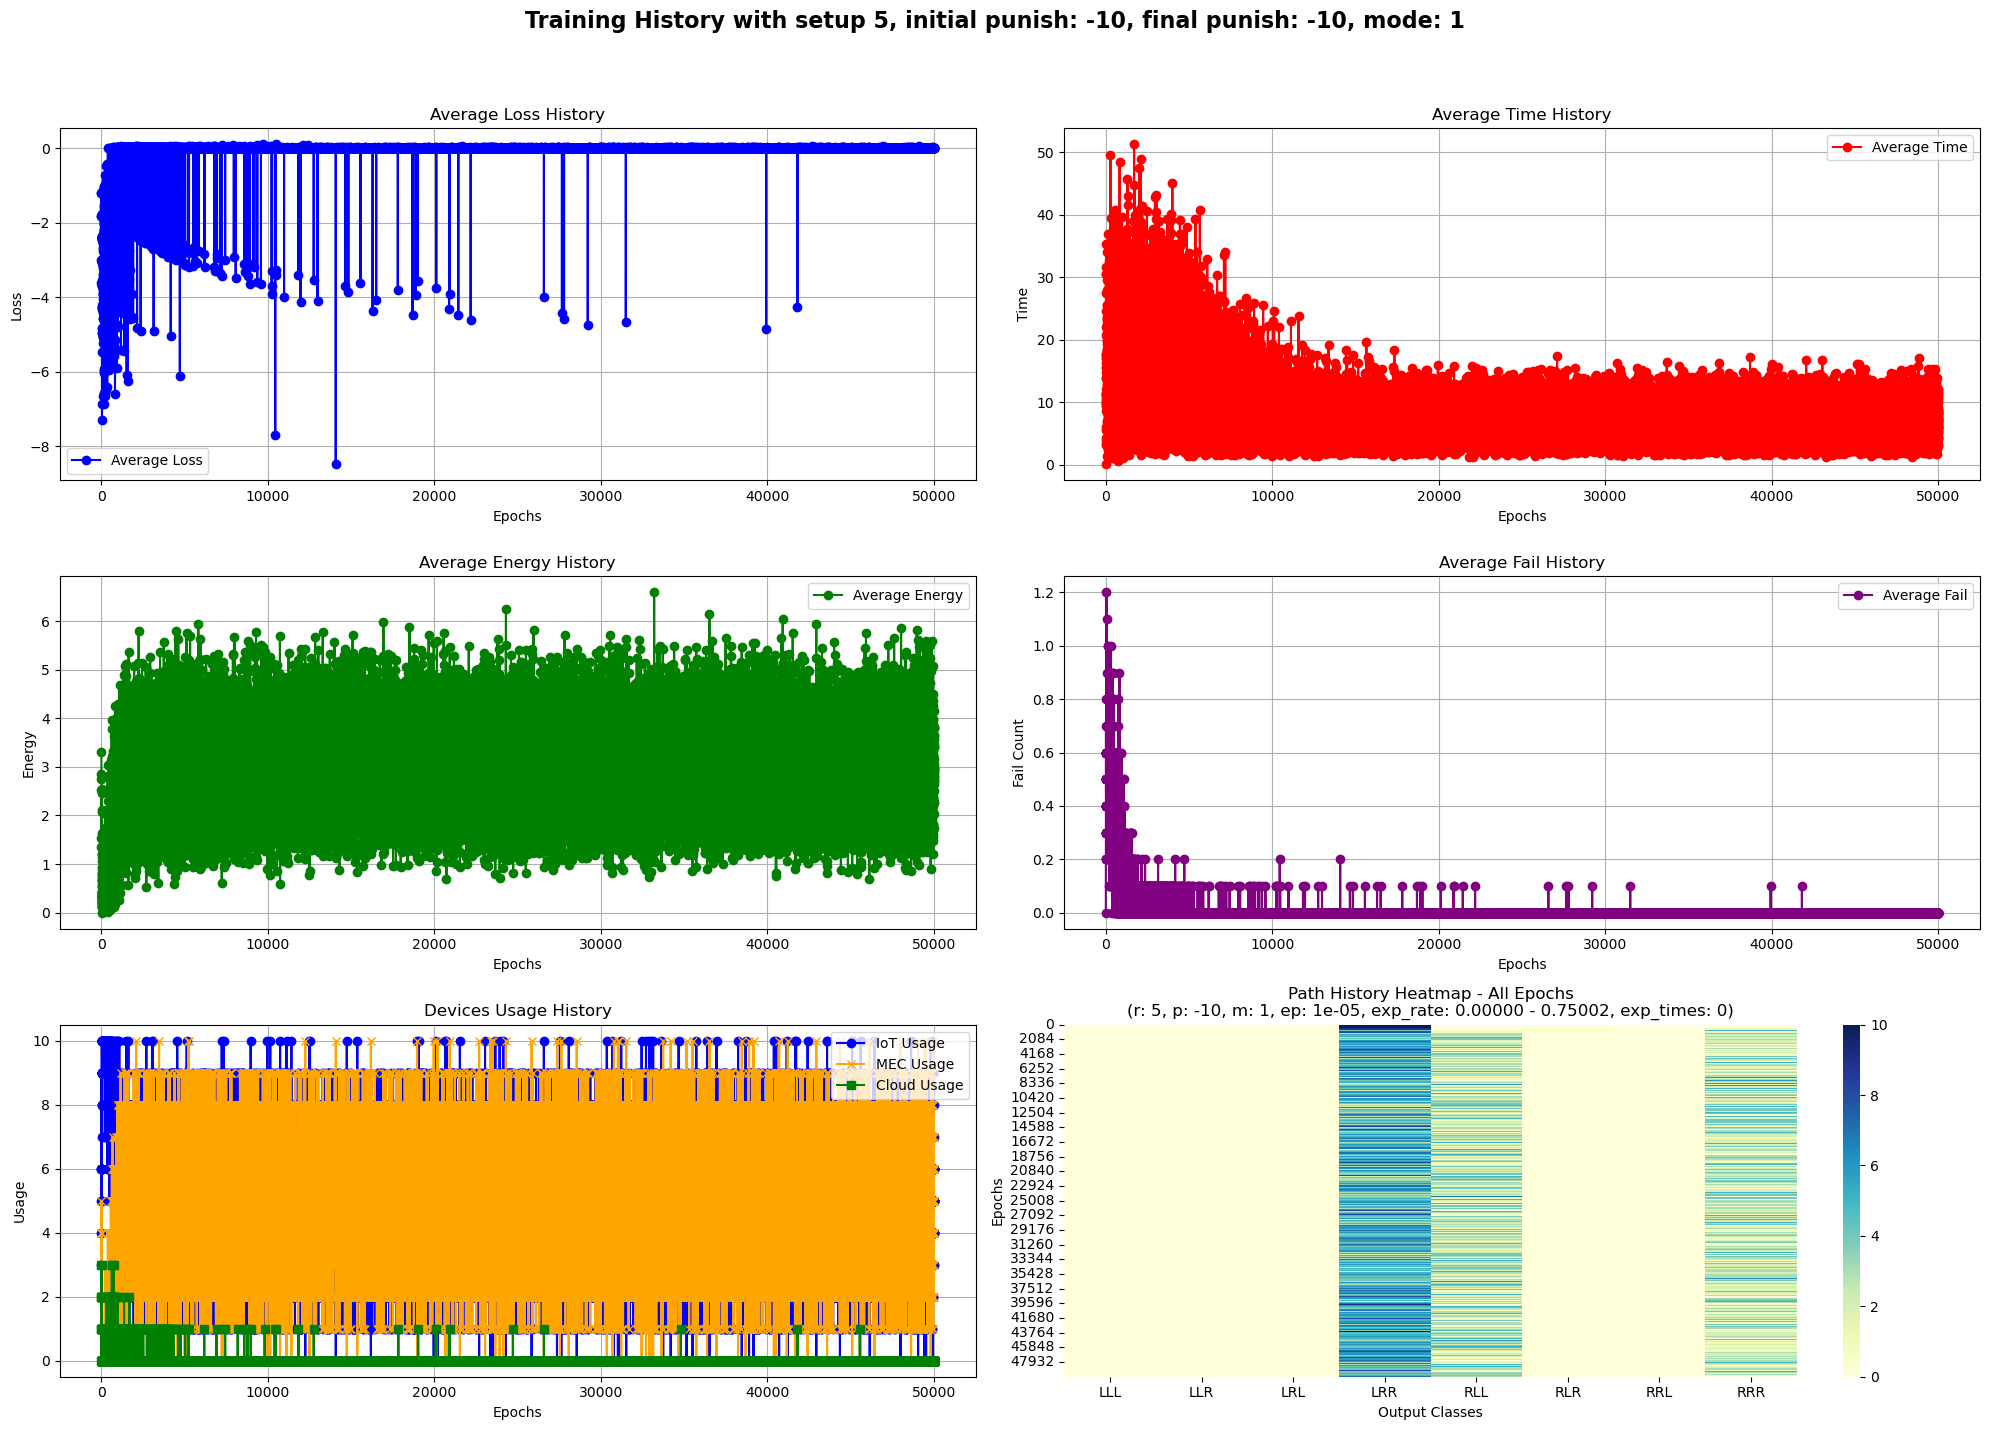

/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/aminsoltani/anaconda3/envs/amin/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416:

punish epsilon:  0
half epochs punish:  -10


KeyboardInterrupt: 

In [39]:

def train_test(n):
    # Without regularization
    # rpSetup_list = {1: [-6], 2: [-1500], 3: [-200], 4: [-100], 5: [-100], 6: [-300], 7: [-1] }
    # With regularization
    # rpSetup_list = {1: [-5], 2: [-2000], 3: [-110], 4: [-600], 5: [-100], 6: [-250], 7: [-0.6] }
    # rpSetup_list = {2: [-2000], 5: [-100], 6: [-250]}
    rpSetup_list = {5: [-10]}

    learning_modes = [1]
    for i in range(n):
        for reward, punishments in rpSetup_list.items():
            for punish, mode in itertools.product(punishments, learning_modes): 
                
                num_epochs = 50001
                num_episodes = 10
                env = Environment(num_epochs, num_episodes, punish)
                
                env.learning_mode = mode
                env.rewardSetup = reward
                env.learning_rate = 0.005
                # env.punish_epsilon = -(punish - (punish * 10)) / (num_epochs / 2)
                env.punish_epsilon = 0
                print("punish epsilon: ", env.punish_epsilon)
                
                tasks, tasks_copy = read_tasks(regular=env.shouldRegular)
                env.tasks = tasks
                env.tasks_copy = tasks_copy
                
                
                tree = env.agent
                env.train(env.num_epochs, env.num_episodes)

train_test(5)   
print("completed")



/var/folders/_r/7fw_p5qd057b2drkmtmpn2l80000gn/T/ipykernel_31560/682789932.py:8: RuntimeWarning: overflow encountered in exp
  return  -np.exp(alpha * e) - np.exp(beta * t)
/var/folders/_r/7fw_p5qd057b2drkmtmpn2l80000gn/T/ipykernel_31560/682789932.py:10: RuntimeWarning: overflow encountered in exp
  return  -np.exp(alpha * e + beta * t)


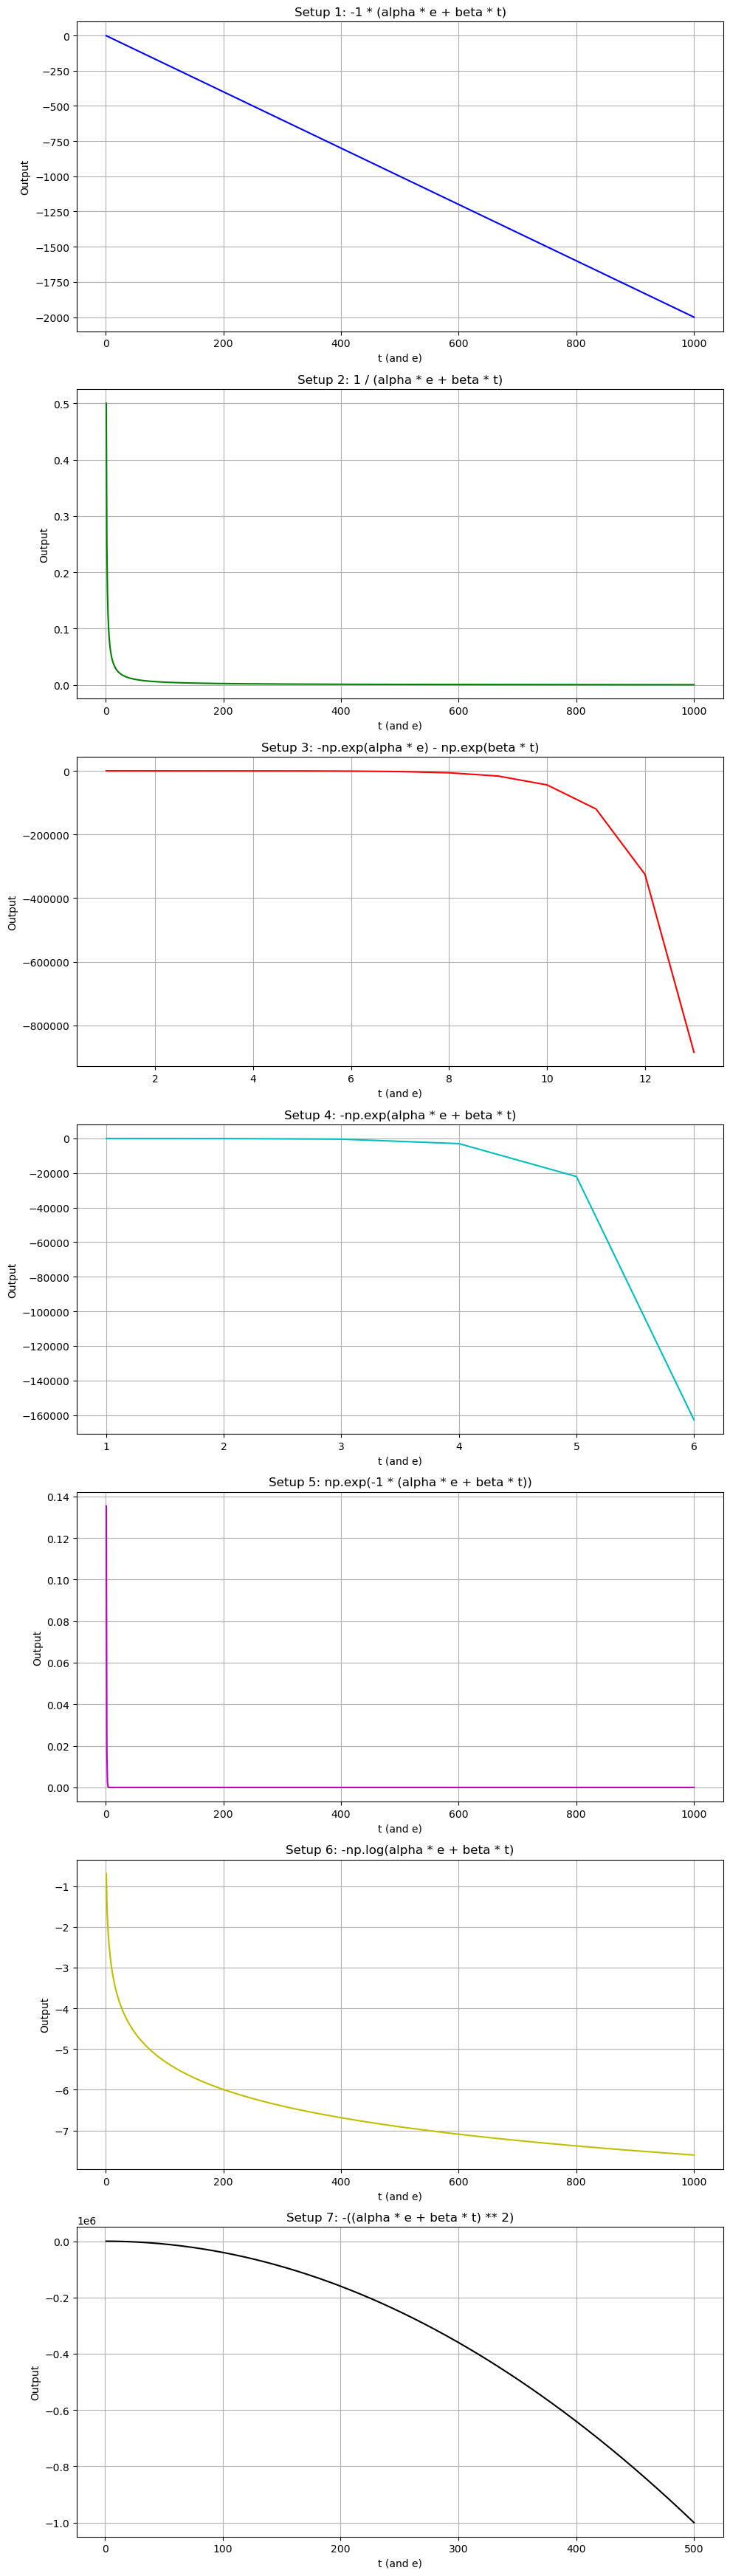

In [92]:
# Define the range for t and e
t_values = np.arange(1, 1001, 1)  # Start from 1 to avoid divide by zero and log(0)
e_values = np.arange(1, 1001, 1)

# Create subplots for each function
fig, axs = plt.subplots(7, 1, figsize=(10, 35))
setups = range(1, 8)
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
titles = [
    "Setup 1: -1 * (alpha * e + beta * t)",
    "Setup 2: 1 / (alpha * e + beta * t)",
    "Setup 3: -np.exp(alpha * e) - np.exp(beta * t)",
    "Setup 4: -np.exp(alpha * e + beta * t)",
    "Setup 5: np.exp(-1 * (alpha * e + beta * t))",
    "Setup 6: -np.log(alpha * e + beta * t)",
    "Setup 7: -((alpha * e + beta * t) ** 2)"
]

for i, setup in enumerate(setups):
    results = []
    for t in t_values:
        e = t  # For simplicity, use e = t
        try:
            result = getSetup(e, t, setup)
            if not np.isfinite(result) or abs(result) > 1e6:  # filter large values to avoid overflow
                result = np.nan
            results.append(result)
        except Exception as ex:
            results.append(np.nan)
    
    axs[i].plot(t_values, results, color=colors[i])
    axs[i].set_title(titles[i])
    axs[i].set_xlabel('t (and e)')
    axs[i].set_ylabel('Output')
    axs[i].grid(True)

plt.tight_layout()
plt.show()

In [93]:
print(np.exp(-2))
print(np.exp(-10))

0.1353352832366127
4.5399929762484854e-05
